![](https://github.com/mccode-dev/PaNRAID/raw/main/images/toplogo-diadem.png)

# CNN classification of generated form-factor NeXus data

This notebook trains a PyTorch CNN to classify `sphere`, `core_shell`, and `linear_pearls` simulations. Each `generated_dataset/<simulation_id>/mccode.h5` file is one example; `simulation_manifest.json` supplies its class label. Missing or invalid runs are excluded before splitting.


In [1]:
from pathlib import Path
import json
import random

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torchvision
from torch.utils.data import DataLoader, Dataset, Subset

SEED = 20260918
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print('PyTorch:', torch.__version__)
print('Device:', DEVICE)


PyTorch: 2.13.0
Device: mps


## Locate completed simulations

The manifest is the authoritative label table. A record becomes eligible only when its expected NeXus file exists. This makes partially completed production runs explicit rather than silently changing labels.


In [32]:
ROOT = Path.cwd().parents[2] / "22_September_Tuesday/05_afternoon_data_generation"
DATA_ROOT = ROOT / 'generated_dataset_with_instrument_variation'
MANIFEST_PATH = ROOT / 'simulation_manifest_with_instrument_variation.json'
CLASS_NAMES = ['sphere', 'core_shell', 'linear_pearls']
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
SIGNAL_PATH = 'entry1/data/PSD_scattering_psd/data'

with MANIFEST_PATH.open() as stream:
    manifest = json.load(stream)

records, missing = [], []
for row in manifest:
    path = DATA_ROOT / row['simulation_id'] / 'mccode.h5'
    if path.is_file():
        records.append({**row, 'path': path, 'label': CLASS_TO_INDEX[row['sample_family']]})
    else:
        missing.append(row['simulation_id'])

print(f'Manifest rows: {len(manifest)}')
print(f'Completed files: {len(records)}')
print(f'Missing files: {len(missing)}')
print('Completed per class:', {name: sum(r['sample_family'] == name for r in records) for name in CLASS_NAMES})


Manifest rows: 1000
Completed files: 1000
Missing files: 0
Completed per class: {'sphere': 334, 'core_shell': 333, 'linear_pearls': 333}


## Dataset and preprocessing

Files are opened lazily inside `__getitem__`, which avoids sharing live HDF5 handles between workers. Preprocessing is supplied to the dataset as a `torchvision.transforms.Compose` pipeline: `ToTensor → Resize(180×180) → ReLU → log1p → maximum normalization`. Per-image scaling emphasizes scattering-pattern shape and removes absolute intensity; omit it when absolute intensity is scientifically meaningful.


In [33]:
detector_transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize((180, 180), antialias=True),
    nn.ReLU(inplace=True),
    torchvision.transforms.Lambda(torch.log1p),
    torchvision.transforms.Lambda(
        lambda image: image / torch.max(image) if torch.max(image) > 0 else image
    ),
])

class FormFactorNexusDataset(Dataset):
    def __init__(self, records, transforms=None):
        self.records = list(records)
        self.transform = transforms

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        with h5py.File(record['path'], 'r') as h5:
            if SIGNAL_PATH not in h5:
                raise KeyError(f"{record['path']}: missing {SIGNAL_PATH}")
            array = np.asarray(h5[SIGNAL_PATH], dtype=np.float32)

        if array.ndim != 2 or not np.isfinite(array).all():
            raise ValueError(f"{record['simulation_id']}: invalid detector array {array.shape}")

        if self.transform is not None:
            array = self.transform(array)

        return array, int(record['label'])

dataset = FormFactorNexusDataset(records, transforms=detector_transforms)
sample, target = dataset[0]
print('Examples:', len(dataset))
print('Image:', sample.shape, sample.dtype)
print('Label:', target, CLASS_NAMES[target])


Examples: 1000
Image: torch.Size([1, 180, 180]) torch.float32
Label: 0 sphere


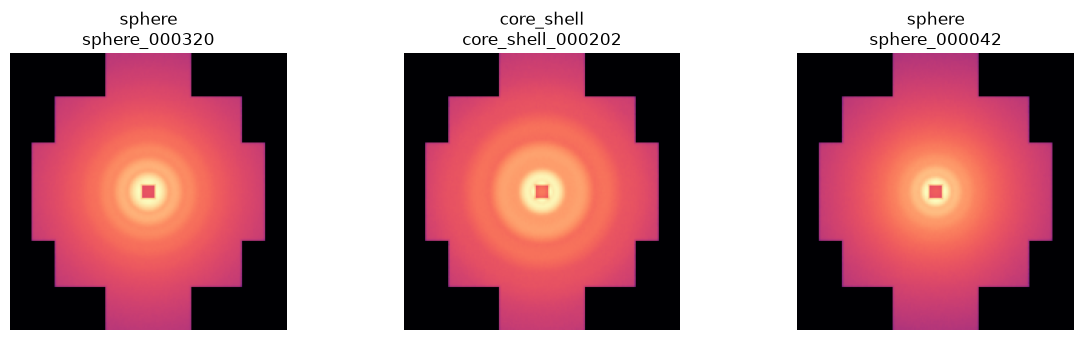

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for label, ax in enumerate(axes):
    index = np.random.choice(len(dataset))
    image, target = dataset[index]
    ax.imshow(image[0], origin='lower', cmap='magma')
    ax.set_title(f'{CLASS_NAMES[target]}\n{records[index]["simulation_id"]}')
    ax.set_axis_off()
plt.tight_layout()


## Reproducible stratified train, validation, and test splits

Splitting is performed separately within each class, using 70% for training, 15% for validation, and 15% for the final test. The test set remains untouched until model selection is complete.


In [40]:
def stratified_indices(records, fractions=(0.70, 0.15, 0.15), seed=SEED):
    if not np.isclose(sum(fractions), 1):
        raise ValueError('fractions must sum to one')
    rng = np.random.default_rng(seed)
    splits = [[], [], []]
    for label in range(len(CLASS_NAMES)):
        indices = np.array([i for i, record in enumerate(records) if record['label'] == label])
        rng.shuffle(indices)
        n_train = int(len(indices) * fractions[0])
        n_validation = int(len(indices) * fractions[1])
        for destination, part in zip(splits, np.split(indices, (n_train, n_train + n_validation))):
            destination.extend(part.tolist())
    for split in splits:
        rng.shuffle(split)
    return splits

train_idx, validation_idx, test_idx = stratified_indices(records)

def class_counts(indices):
    return np.bincount([records[i]['label'] for i in indices], minlength=len(CLASS_NAMES))

for name, indices in [('train', train_idx), ('validation', validation_idx), ('test', test_idx)]:
    print(f'{name:10s}: {len(indices):3d}', dict(zip(CLASS_NAMES, class_counts(indices))))

assert not (set(train_idx) & set(validation_idx) or set(train_idx) & set(test_idx) or set(validation_idx) & set(test_idx))


train     : 699 {'sphere': np.int64(233), 'core_shell': np.int64(233), 'linear_pearls': np.int64(233)}
validation: 148 {'sphere': np.int64(50), 'core_shell': np.int64(49), 'linear_pearls': np.int64(49)}
test      : 153 {'sphere': np.int64(51), 'core_shell': np.int64(51), 'linear_pearls': np.int64(51)}


In [41]:
BATCH_SIZE = 32
loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(Subset(dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, generator=loader_generator)
validation_loader = DataLoader(Subset(dataset, validation_idx), batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0)
test_loader = DataLoader(Subset(dataset, test_idx), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
print('Images:', images.shape)
print('Labels:', labels.shape, labels.dtype)


Images: torch.Size([32, 1, 180, 180])
Labels: torch.Size([32]) torch.int64


## CNN model

The CNN learns local detector patterns. Adaptive pooling makes the classifier independent of the exact detector resolution. `CrossEntropyLoss` expects raw logits, so `forward` intentionally contains no softmax.


In [42]:
class DetectorCNN(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((3, 3)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 3 * 3, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )

    def forward(self, image):
        return self.classifier(self.features(image))

model = DetectorCNN(len(CLASS_NAMES)).to(DEVICE)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))


DetectorCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(3, 3))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=576, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.

## Train and select the best validation checkpoint

Class weights are computed from the training subset only. The best validation-loss state is restored before the test set is evaluated.


In [43]:
train_counts = torch.tensor(class_counts(train_idx), dtype=torch.float32)
class_weights = train_counts.sum() / (len(CLASS_NAMES) * train_counts)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
print('Class weights:', dict(zip(CLASS_NAMES, class_weights.tolist())))


Class weights: {'sphere': 1.0, 'core_shell': 1.0, 'linear_pearls': 1.0}


In [44]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = total_correct = total_examples = 0
    context = torch.enable_grad() if training else torch.inference_mode()
    with context:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_examples += labels.numel()
            total_loss += loss.item() * labels.numel()
            total_correct += (logits.argmax(1) == labels).sum().item()
    return {'loss': total_loss / total_examples, 'accuracy': total_correct / total_examples}

EPOCHS = 15
history = []
best_validation_loss = float('inf')
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, criterion, DEVICE, optimizer)
    validation_metrics = run_epoch(model, validation_loader, criterion, DEVICE)
    history.append({'epoch': epoch, 'train': train_metrics, 'validation': validation_metrics})
    if validation_metrics['loss'] < best_validation_loss:
        best_validation_loss = validation_metrics['loss']
        best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
    print(f'Epoch {epoch:02d} | train loss {train_metrics["loss"]:.4f}, acc {train_metrics["accuracy"]:.3f} '
          f'| validation loss {validation_metrics["loss"]:.4f}, acc {validation_metrics["accuracy"]:.3f}')

model.load_state_dict(best_state)


Epoch 01 | train loss 0.7130, acc 0.651 | validation loss 1.0163, acc 0.338
Epoch 02 | train loss 0.5024, acc 0.648 | validation loss 0.6928, acc 0.588
Epoch 03 | train loss 0.4841, acc 0.671 | validation loss 0.4734, acc 0.676
Epoch 04 | train loss 0.4772, acc 0.672 | validation loss 0.4668, acc 0.662
Epoch 05 | train loss 0.4746, acc 0.671 | validation loss 0.4664, acc 0.669
Epoch 06 | train loss 0.4675, acc 0.691 | validation loss 0.4796, acc 0.669
Epoch 07 | train loss 0.4832, acc 0.648 | validation loss 0.4638, acc 0.669
Epoch 08 | train loss 0.4663, acc 0.688 | validation loss 0.4560, acc 0.696
Epoch 09 | train loss 0.4775, acc 0.701 | validation loss 0.4867, acc 0.655
Epoch 10 | train loss 0.4677, acc 0.680 | validation loss 0.4640, acc 0.709
Epoch 11 | train loss 0.4602, acc 0.705 | validation loss 0.4557, acc 0.689
Epoch 12 | train loss 0.4598, acc 0.700 | validation loss 0.4521, acc 0.709
Epoch 13 | train loss 0.4657, acc 0.687 | validation loss 0.4696, acc 0.669
Epoch 14 | t

<All keys matched successfully>

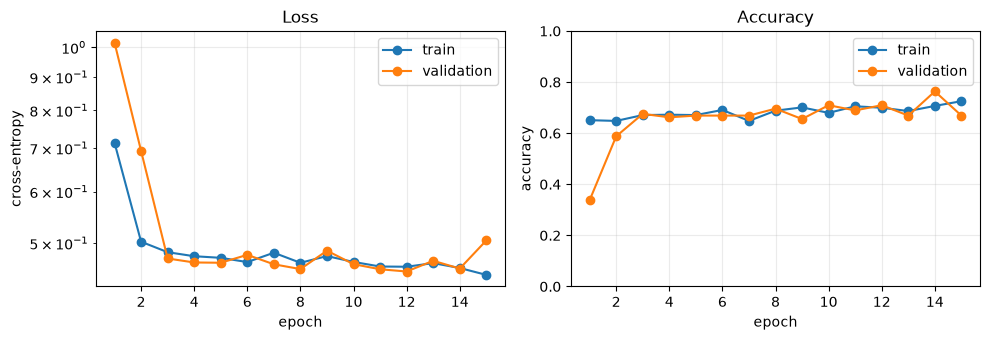

In [45]:
epochs = [row['epoch'] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for split in ('train', 'validation'):
    axes[0].semilogy(epochs, [row[split]['loss'] for row in history], marker='o', label=split)
    axes[1].plot(epochs, [row[split]['accuracy'] for row in history], marker='o', label=split)
axes[0].set(xlabel='epoch', ylabel='cross-entropy', title='Loss')
axes[1].set(xlabel='epoch', ylabel='accuracy', ylim=(0, 1), title='Accuracy')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)
plt.tight_layout()


## Final test accuracy

The test set is evaluated once after restoring the best validation checkpoint. The confusion matrix reports both counts and row-normalized recall.


Test accuracy: 0.739 (113/153)
sphere         recall: 0.255
core_shell     recall: 0.961
linear_pearls  recall: 1.000


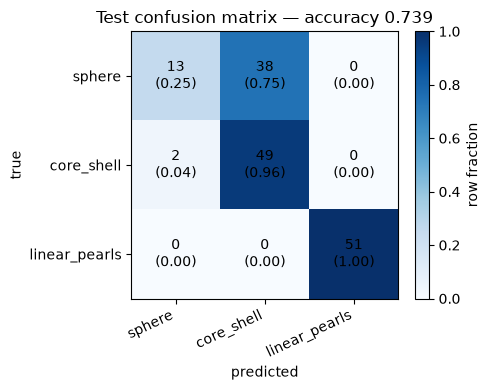

In [47]:
def collect_predictions(model, loader, device):
    model.eval()
    truth, predicted = [], []
    with torch.inference_mode():
        for images, labels in loader:
            logits = model(images.to(device))
            truth.extend(labels.tolist())
            predicted.extend(logits.argmax(1).cpu().tolist())
    return np.asarray(truth), np.asarray(predicted)

y_true, y_pred = collect_predictions(model, test_loader, DEVICE)
test_ids = [records[index]['simulation_id'] for index in test_idx]
confusion = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int)
np.add.at(confusion, (y_true, y_pred), 1)
test_accuracy = float((y_true == y_pred).mean())
recall = np.diag(confusion) / np.maximum(confusion.sum(axis=1), 1)

print(f'Test accuracy: {test_accuracy:.3f} ({(y_true == y_pred).sum()}/{len(y_true)})')
for name, value in zip(CLASS_NAMES, recall):
    print(f'{name:14s} recall: {value:.3f}')

normalized = confusion / np.maximum(confusion.sum(axis=1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(5, 4))
handle = ax.imshow(normalized, vmin=0, vmax=1, cmap='Blues')
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, f'{confusion[i, j]}\n({normalized[i, j]:.2f})', ha='center', va='center')
ax.set(xticks=range(3), yticks=range(3), xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
       xlabel='predicted', ylabel='true', title=f'Test confusion matrix — accuracy {test_accuracy:.3f}')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
fig.colorbar(handle, ax=ax, label='row fraction')
plt.tight_layout()


## Optional checkpoint

A useful checkpoint includes preprocessing, class order, split identifiers, training history, and metrics—not only model weights.


In [30]:
SAVE_CHECKPOINT = False
checkpoint = {
    'model_state': {name: value.detach().cpu() for name, value in model.state_dict().items()},
    'class_names': CLASS_NAMES,
    'image_size': (180, 180),
    'signal_path': SIGNAL_PATH,
    'preprocessing': 'ToTensor -> bilinear antialiased Resize(180,180) -> ReLU -> log1p -> per-image maximum',
    'seed': SEED,
    'train_ids': [records[i]['simulation_id'] for i in train_idx],
    'validation_ids': [records[i]['simulation_id'] for i in validation_idx],
    'test_ids': test_ids,
    'history': history,
    'test_accuracy': test_accuracy,
}
if SAVE_CHECKPOINT:
    torch.save(checkpoint, 'form_factor_cnn.pt')
    print('Saved form_factor_cnn.pt')
else:
    print('Set SAVE_CHECKPOINT=True to save form_factor_cnn.pt')


Set SAVE_CHECKPOINT=True to save form_factor_cnn.pt
